<h1>-----------------------------------------</h1>
<h1>III. Explore ensemble solar forecast     </h1>
<h1>-----------------------------------------</h1>

Ensemble forecast are the most common probabilistic forecast issued by Numerical Weather Prediction (NWP) systems. The aim of this Notebook is to visualize and explore ensemble forecast of solar irradiance released by ECMWF for the Terre Sainte campus in La Reunion.

<h2>What is the ensemble prediction system (EPS) generated by ECMWF?</h2>

An EPS is a set of deterministic forecasts of possible trajectories of the future weather. To generate this set:
* The NWP model (IFS) produces a baseline deterministic forecast, called "control forecast", which is equivalent to the High Resolution determinitic forecast used in the Jupyter Notebooks 1 and 2.
* Initial conditions and parameters of the control forecast run are preturbed to generate "m" deterministic forecasts called "perturbed forecasts".

If we assume an equal probability of these 51 members, the EPS represents the probabilistic distribution of the possible future weather.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import fsspec

<h2>Load and read the data</h2>

The data used in this exercice are publicly available in a GitHub repository of the research lab. PIMENT, University of La Reunion ([Probabilistic_solar_forecast_lesson](https://github.com/Laboratoire-Piment/Probabilistic_solar_forecast_lesson)). If you copy and use this Jupyter Notebook on your computer, adapt the path to the data file.

We will use a NetCDF file containing the 51 EPS members of ECMWF, the corresponding observations and the clear sky conditions, covering 6 month from July 1st to December 31st 2022. The forecast cover a single location, the Terre sainte campus in La Reunion, where high quality solar measurments are available (21.333°S, 51,483°E, 75m, UTC+4h).

In [2]:
# Dowload the required data from GitHub (https://github.com/Laboratoire-Piment/Probabilistic_solar_forecast_lesson)
destination = "temp/nwp_eps_1h.nc"
fs = fsspec.filesystem("github", org="Laboratoire-Piment", repo="Probabilistic_solar_forecast_lesson")
fs.get("Data/nwp_eps_1h.nc", destination)

# Read and display the file content
ds_eps = xr.open_dataset("temp/nwp_eps_1h.nc")
ds_eps

/tmp/ipykernel_336/2341538222.py:7: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_eps = xr.open_dataset("temp/nwp_eps_1h.nc")


<xarray.Dataset> Size: 4MB
Dimensions:    (basetime: 181, step: 49, member: 50)
Coordinates:
  * basetime   (basetime) datetime64[ns] 1kB 2022-07-01 ... 2022-12-28
  * step       (step) timedelta64[ns] 392B 00:00:00 01:00:00 ... 2 days 00:00:00
  * member     (member) int32 200B 1 2 3 4 5 6 7 8 9 ... 43 44 45 46 47 48 49 50
    latitude   float64 8B ...
    longitude  float64 8B ...
Data variables:
    GHI_pf     (basetime, step, member) float64 4MB ...
    GHI_cf     (basetime, step) float64 71kB ...
    GHI_meas   (basetime, step) float64 71kB ...
    GHI_clear  (basetime, step) float64 71kB ...
    zenith     (basetime, step) float64 71kB ...
Attributes:
    Conventions:  CF-1.6
    history:      2026-02-08 12:32:55 GMT by grib_to_netcdf-2.39.4: /opt/ecmw...

<h2>Information on NetCDF file</h2>

<h3>Dimensions:</h3>

* <b>basetime</b>: Representing the time when the forecast is done
* <b>step</b>: Steps indicating the time steps from the base time, also called horizon
* <b>member</b>: Number of the EPS members

<h3>Coordinates:</h3>

* <b>basetime</b>: A datetime coordinate
* <b>step</b>: A timedelta coordinate representing the time steps after the base time
* <b>member</b>: A integer representing the number of the EPS members
* <b>latitude</b>: Gives the value in degrees of the location latitude
* <b>longitude</b>: Gives the value in degrees of the location longitude

<h3>Data Variables:</h3>

* <b>GHI_cf</b>: Forecasted GHI ($W.m^{-2}$) of the control forecast for each of combination of `basetime` and `step`.
* <b>GHI_pf</b>: Forecasted GHI ($W.m^{-2}$) of the perturbed forecasts for each combination of `basetime`, `step`  and `memeber`.
* <b>GHI_clear</b>: GHI ($W.m^{-2}$) from Copernicus Atmosphere Monitoring Service (CAMS) McClear Clear-Sky for each combination of `basetime` and `step`.
* <b>GHI_meas</b>: Measured GHI ($W.m^{-2}$) for each combination of `basetime` and `step`.
* <b>zenith</b>: Solar zenith angle (°) for each combination of `basetime` and `step`.

<h2>Exercise 1: Display the Dataset</h2>

Display the contents of the `ds_eps` dataset to understand its structure and variables.

* What period is covered by the data set?
* What is the basetimes frequency?
* What is the maximum forecast horizon?
* What is lead-time frequency (e.g. temporal resolution of the forecast)?

In [3]:
# Period covered by the data
print('Start date: ', ds_eps.basetime.min().values)
print('End date: ', ds_eps.basetime.max().values)

# Basetime frequency
print('Basetime frequency: ', pd.to_timedelta((ds_eps.basetime[1]-ds_eps.basetime[0]).values))

# Maximum horizon
print('Maximum horizon: ', pd.to_timedelta(ds_eps.step.max().values))

# Time resolution
print('Temporal resolution: ', pd.to_timedelta((ds_eps.step[1]-ds_eps.step[0]).values))

Start date:  2022-07-01T00:00:00.000000000
End date:  2022-12-28T00:00:00.000000000
Basetime frequency:  1 days 00:00:00
Maximum horizon:  2 days 00:00:00
Temporal resolution:  0 days 01:00:00


<h2>Exercise 2: Plotting one basetime run</h2>

* Plot the first forecast basetime, i.e. all steps for the first base time, corresponding observations and cleaf sky GHI
* Plot the first basetime over "forecast valid time" ("basetime + step", datetime)
* Change the basetime to find clear sky and overcast days

Questions
* Does the control forecast correspond to the median trajectory?
* Does the ensemble systematically bound the observations?

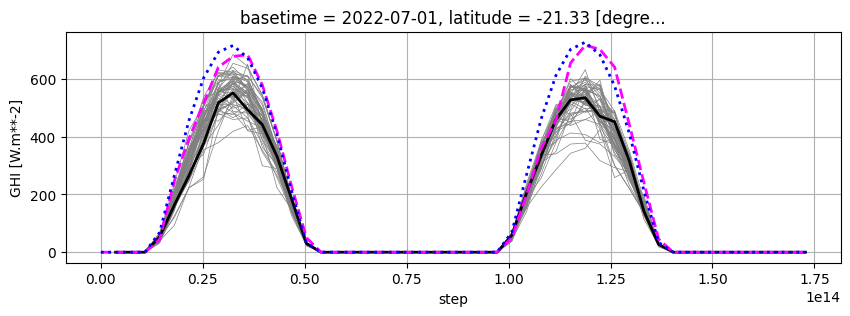

In [4]:
# Select basetime
bs = 0

plt.rcParams.update({'font.size': 10})
plt.figure(figsize=[10, 3])
for m in np.arange(50):
    ds_eps['GHI_pf'].isel(basetime=bs, member=m).plot(color='grey', linewidth=0.5)
ds_eps['GHI_cf'].isel(basetime=bs).plot(color='black', linewidth=2)
ds_eps['GHI_meas'].isel(basetime=bs).plot(color='magenta', linewidth=2, linestyle='dashed')
ds_eps['GHI_clear'].isel(basetime=bs).plot(color='blue', linewidth=2, linestyle='dotted')
plt.grid()

<h2>Exercice 3: Plot predictive intervals derived from the ensemble</h2>

Prediction intervals are another graphical representation used to display a probabilistic forecast. They define the areas where the outcome will occur with a certain level of probability.
* Select a basetime
* Rank the members at each step
* Compute the lower and upper limit of the 4 predictive intervals: 100% [0,1], 80% [0.1,0.9], 60% [0.2,0.8], and 20% [0.4,0.6]
* Plot the predictive interval with a color scale

Questions
* What does a 60% prediction interval mean?
* What is the relationship between predictive intervals and sharpness?
* Based on all the plots displayed in this Jupyter Notebook, what can you say about the quality of the raw EPS provided by ECMWF?

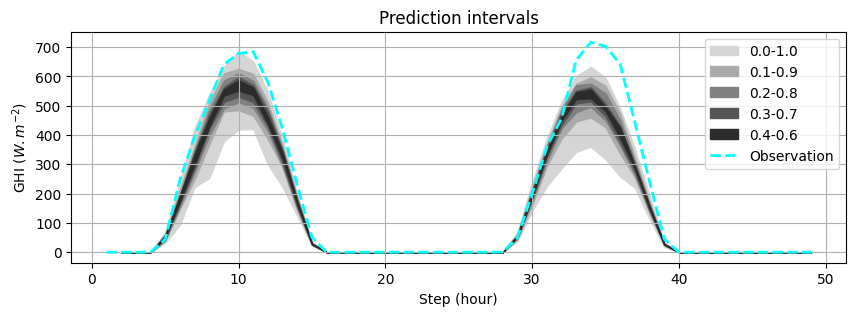

In [5]:
# Select basetime
bs = 0

# Extract, rank and put the memebers in a DataFrame
eps = np.concatenate((ds_eps['GHI_pf'].isel(basetime=bs).values.T,
                        [ds_eps['GHI_cf'].isel(basetime=bs).values]), axis=0)
eps = np.sort(eps.T, axis=1) # Rank
obs = ds_eps.isel(basetime=bs)[['GHI_meas']].to_array().values.T
x = np.arange(ds_eps.step.count())+1
quantiles = np.arange(eps.shape[1])/(eps.shape[1]-1)

# Plotting
plt.rcParams.update({'font.size': 10})
plt.figure(figsize=[10, 3])
for quant in np.arange(0,25,5):
    lab = str(quantiles[quant]) + '-' + str(quantiles[50-quant])
    plt.fill_between(x, eps[:,quant], eps[:,50-quant], color=str((5 - quant/5) / 6), label=lab)
plt.plot(x, obs, color='cyan', linewidth=2, linestyle='dashed', label='Observation')
plt.ylabel('GHI ($W.m^{-2}$)')
plt.xlabel('Step (hour)')
plt.title('Prediction intervals')
plt.grid()
plt.legend()

<h2>Exercice 4: Plotting the EPS as a Cumulative Distribution Fonction (CDF)</h2>

EPS is a first type of probabilistic forecast. As such, it is important to visualize the corresponding CDF. To plot a CDF from an an ensemble:
* Rank the EPS members in acending order
* Assign a cumulative probability to each member
* Plot the ensemble as a CDF assuming a probability jump of $\frac{1}{M}$ between the $M$ members of the EPS (classical representation)

You can also add the CDF of the corresponding observation (We assume no uncertainty on the observation, thus the CDF is a dirac or step function.)

<h3>Function to plot the CDF from the EPS members</h3>

In [6]:
def plot_eps_cdf(eps, obs, fig_size, xaxis_lim):
  # INPUTS
  #   eps: Vector with the ensemble members of size
  #   obs: Observation value
  #   plot_title: Title of the figure (string)

  # Assign cumulative probabilities to members
  m = len(eps) # Number of members
  eps_prob = np.arange(0,1,1/(m)) # Vector of cumulative probabilities of the ensemble members

  # Sort members in ascending order
  eps = np.sort(eps)

  # Oservation step function and corresponding cumulative probability
  step_func_obs = np.array([obs,obs])
  step_func_obs_prob = np.array([0.0,1.0])

  #Add lower and upper limits to ensemble and observation CDFs
  low = np.min([eps.min(),obs])-10 # Lower limit
  up = np.max([eps.max(),obs])+10 # Upper limit
  eps = np.concat((low, eps, up), axis=None)
  eps_prob = np.concat((0.0, eps_prob, 1.0), axis=None)
  step_func_obs = np.concat((low, step_func_obs, up), axis=None)
  step_func_obs_prob = np.concat((0.0, step_func_obs_prob, 1.0), axis=None)

  # Plotting
  plt.rcParams.update({'font.size': 10})
  plt.figure(figsize=fig_size)
  plt.step(eps, eps_prob, where='pre',
          color='grey', label='Ensemble') # Plot ensemble CDF
  plt.step(step_func_obs, step_func_obs_prob, where='pre',
          color='magenta', linestyle='dashed', label='Observation') # Plot observation CDF step function
  plt.xlabel('GHI quantiles ($W.m^{-2}$)')  # X-axis label
  plt.xlim(xaxis_lim)
  plt.ylabel('Cumulative probability')  # Y-axis label
  plt.grid()
  plt.legend()

<h3>Plot the enseamble and observation CDFs for specific step</h3>

Use the function above to plot the 2 CDFs for a specific forecast/observation pair:
* Select a basetime and a step
* Extract from the Dataset ds_eps and Gather the forecast members (control forecast + perturbed forecasts) in a single vector
* Extract the corresponding observation from the Dataset ds_eps
* Plot the CDFs using the function rank_hist

Questions
* Can you detail the elements of the CDF plot (axes, meanings of a point on a curve)?
* Why does the CDF exhibit steps?
* If you change the basetime or step, and then plot a new CDF, what are the changes?


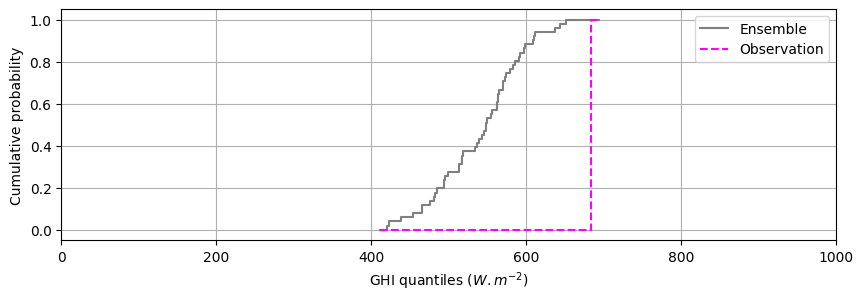

In [7]:
# Select basetime and step
bs = 0
st = 10

# Extract and put the member values in a DataFrame
eps = np.concat((ds_eps['GHI_cf'].isel(basetime=bs, step=st).values,
                 ds_eps['GHI_pf'].isel(basetime=bs, step=st).values), axis=None)

# Extract corresponding observation
obs = ds_eps['GHI_meas'].isel(basetime=bs, step=st).values

# Plot CDFs
plot_eps_cdf(eps, obs, [10,3], [0,1000])

<h2>Exercice 5: Plotting the perdiction intervals and ensemble CDF</h2>

Plotting the CDF alone is a very abstract way of representing a probabilistic forecast. Perhaps if we also show where the cumulative distribution function (CDF) comes from, you will understand more concretely what a predictive CDF is. To do so:
* Join the plots obtained in Exercices 3 and 4
* On the first plot (Exercice 3), add a vertical line to indicate which step corresponds to the CDF

Questions
* Sharpness of a predictive CDF is an important feature of probabilistic forecast. Find a step with low-sharpness and a step with a high-sharpness.
* What CDF shape indicates a low-sharpness probabilistc forecast?
* Is the sharpness an indicator of probabilistic forecast quality?

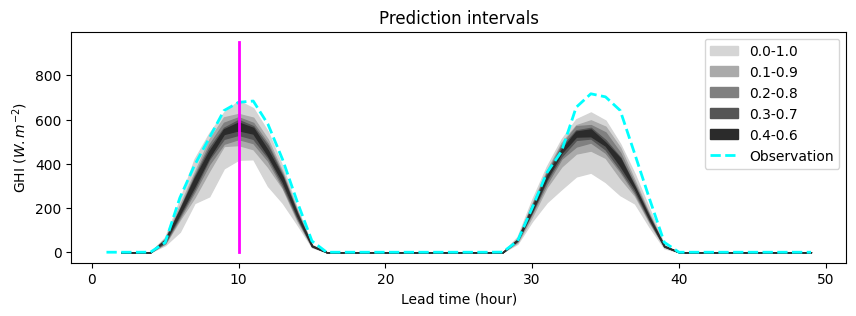

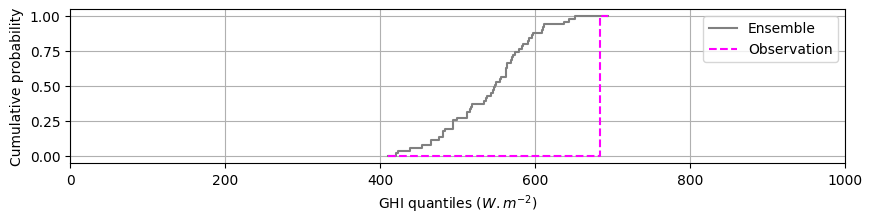

In [8]:
# Select basetime and step
bs = 0
st = 10

# Extract, rank and put the memebers in a DataFrame
eps = np.concatenate((ds_eps['GHI_pf'].isel(basetime=bs).values.T,
                        [ds_eps['GHI_cf'].isel(basetime=bs).values]), axis=0)
eps = np.sort(eps.T, axis=1) # Rank
obs = ds_eps.isel(basetime=bs)[['GHI_meas']].to_array().values.T
x = np.arange(ds_eps.step.count())+1
quantiles = np.arange(eps.shape[1])/(eps.shape[1]-1)

# Plotting
plt.rcParams.update({'font.size': 10})
plt.figure(figsize=[10, 3])
for quant in np.arange(0,25,5):
    lab = str(quantiles[quant]) + '-' + str(quantiles[50-quant])
    plt.fill_between(x, eps[:,quant], eps[:,50-quant], color=str((5 - quant/5) / 6), label=lab)
plt.plot(x, obs, color='cyan', linewidth=2, linestyle='dashed', label='Observation')
plt.ylabel('GHI ($W.m^{-2}$)')
plt.xlabel('Step (hour)')
plt.title('Prediction intervals')
plt.grid()
plt.legend()

# Add a vertical line corresponding to the selected step (when the CDF comes from)
plt.plot([st,st],[0,950],
         color='magenta', linewidth=2, linestyle='solid')
plt.ylabel('GHI ($W.m^{-2}$)')
plt.xlabel('Lead time (hour)')
plt.grid()

# Plot the CDF
# Extract and put the member values in a DataFrame
eps = np.concat((ds_eps['GHI_cf'].isel(basetime=bs, step=st).values,
                 ds_eps['GHI_pf'].isel(basetime=bs, step=st).values), axis=None)

# Extract corresponding observation
obs = ds_eps['GHI_meas'].isel(basetime=bs, step=st).values

# Plotting
plot_eps_cdf(eps, obs, [10,2], [0,1000])